#Experiment 2
##Date - 13 / 7 / 2026

In [ ]:
import nltk
import matplotlib.pyplot as plt
import random

In [ ]:
nltk.download('twitter_samples')

[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!


True

In [ ]:
from nltk.corpus import twitter_samples

In [ ]:
tweets = twitter_samples.strings()
type(tweets)

list

In [ ]:
tweets

['hopeless for tmr :(',
 "Everything in the kids section of IKEA is so cute. Shame I'm nearly 19 in 2 months :(",
 '@Hegelbon That heart sliding into the waste basket. :(',
 '“@ketchBurning: I hate Japanese call him "bani" :( :(”\n\nMe too',
 'Dang starting next week I have "work" :(',
 "oh god, my babies' faces :( https://t.co/9fcwGvaki0",
 '@RileyMcDonough make me smile :((',
 '@f0ggstar @stuartthull work neighbour on motors. Asked why and he said hates the updates on search :( http://t.co/XvmTUikWln',
 'why?:("@tahuodyy: sialan:( https://t.co/Hv1i0xcrL2"',
 'Athabasca glacier was there in #1948 :-( #athabasca #glacier #jasper #jaspernationalpark #alberta #explorealberta #… http://t.co/dZZdqmf7Cz',
 "I have a really good m&amp;g idea but I'm never going to meet them :(((",
 '@Rampageinthebox mare ivan :(',
 '@SophiaMascardo happy trip, keep safe. see you soon :* :(',
 "I'm so tired hahahah :(",
 '@GrumpyCockney With knee replacements they get you up &amp; about the same day. :-(   Ou

In [ ]:
len(tweets)

30000

In [ ]:
import pandas as pd
all_tweets = pd.DataFrame(tweets,columns=["Tweets"])
all_tweets.head()

,Tweets
0,hopeless for tmr :(
1,Everything in the kids section of IKEA is so cute. Shame I'm nearly 19 in 2 months :(
2,@Hegelbon That heart sliding into the waste basket. :(
3,"“@ketchBurning: I hate Japanese call him ""bani"" :( :(”\n\nMe too"
4,"Dang starting next week I have ""work"" :("


In [ ]:
all_tweets.describe()

,Tweets
count,30000
unique,20416
top,"RT @Tommy_Colc: Financial Times come out in support of Tories claiming Miliband is ""preoccupied w/ inequality"". The man who wrote it http:/…"
freq,491


In [ ]:
twitter_samples.fileids()

['negative_tweets.json', 'positive_tweets.json', 'tweets.20150430-223406.json']

In [ ]:
positive_tweets = twitter_samples.strings('positive_tweets.json')
negative_tweets = twitter_samples.strings('negative_tweets.json')

In [ ]:
print(len(negative_tweets))
negative_tweets[153]

5000


'@neikmat Sorry :('

In [ ]:
print(len(positive_tweets))
positive_tweets[42]

5000


'@AquaDesignGroup Thank you for the shout out. Have a great Friday :)'

In [ ]:
positive_tweets = pd.DataFrame(positive_tweets,columns=["Tweets"])
positive_tweets["Sentiments"] = "positive"

negative_tweets = pd.DataFrame(negative_tweets,columns=["Tweets"])
negative_tweets["Sentiments"] = "negative"

In [ ]:
tweets = pd.concat([positive_tweets,negative_tweets],ignore_index=True)
tweets = tweets.sample(frac=1).reset_index(drop=True)
tweets

,Tweets,Sentiments
0,everything reminds me of u :-(,negative
1,@niftyplayer @greyfool Sir I wish such detailed data was available in India :-),positive
2,#FollowFriday @IzywayLesExpats @na4innov @InXpressCoAzur for being top engaged members in my community this week :),positive
3,"Lol the person i want to hug i cant :( lmbo dangit i miss people to much , cant help it though",negative
4,I don't sleep enough :(,negative
...,...,...
9995,@MaxivisionEye Many thanks to all :),positive
9996,GUYS add my KIK - therver85552 #kik #hornykik #bestoftheday #girls #wife #premiostumundo #oralsex :) http://t.co/bgO0CgYWzj,positive
9997,Future didn't show up :(,negative
9998,Anyone wanna skype me? :D,positive


In [ ]:
print(tweets[tweets["Sentiments"]=="positive"].value_counts().sum())
print(tweets[tweets["Sentiments"]=="negative"].value_counts().sum())

5000
5000


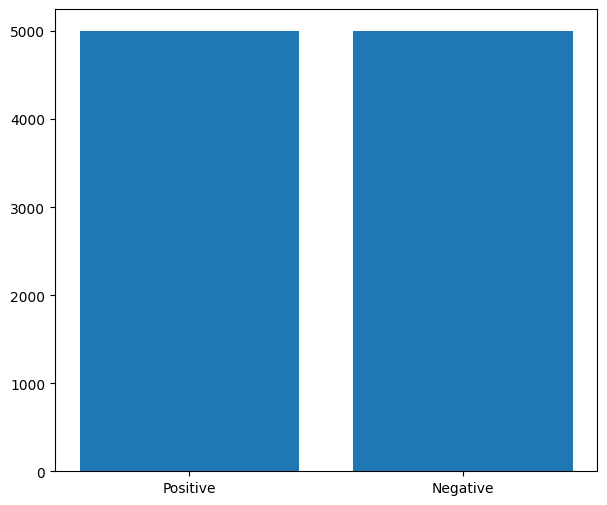

In [ ]:
fig = plt.figure(figsize=(7,6))
labels = "Positive", "Negative"
sizes = [tweets[tweets["Sentiments"]=="positive"].value_counts().sum(),tweets[tweets["Sentiments"]=="negative"].value_counts().sum()]
plt.bar(labels,sizes)
plt.show()

preprocess

In [ ]:
tweet = positive_tweets.iloc[677]
print(tweet)

Tweets        @dreesti \nWaiter: here is your bill sir??\nCustomer: Ok, where is the kitchen??\n:D
Sentiments                                                                                positive
Name: 677, dtype: object


In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
tweet1 = all_tweets.iloc[667]
tweet1["Tweets"]

'Home alone :('

In [ ]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer

In [ ]:
tweet1 = tweets["Tweets"][667]
tweet1

'Feels like a lifetime ! We finish on the same day :( !! Party time @xBethanyOystonx Xxx'

In [ ]:
#remove old style txt "RT"
tweet2 = re.sub(r'^RT[\s]+','',tweet1)

#remove hyperlinks
tweet2 = re.sub(r'https?://[^\s\n\r]+','',tweet2)

#only removing th hash sign from the word
tweet2 = re.sub(r'@\w+','',tweet2)
tweet2 = re.sub(r'#','',tweet2)
tweet2 = re.sub(r'[:)|:(]','',tweet2)
print(tweet1)
print("cleanded tweet:",tweet2)



Feels like a lifetime ! We finish on the same day :( !! Party time @xBethanyOystonx Xxx
cleanded tweet: Feels like a lifetime ! We finish on the same day  !! Party time  Xxx


In [ ]:
tokenizer = TweetTokenizer(preserve_case=False,strip_handles=True,reduce_len=True)

tweet_token = tokenizer.tokenize(tweet2)

print("token string:")
print(tweet_token)

token string:
['feels', 'like', 'a', 'lifetime', '!', 'we', 'finish', 'on', 'the', 'same', 'day', '!', '!', 'party', 'time', 'xxx']


Stop words and punctuations

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
stopwords_english = stopwords.words('english')

print('Stop words:',stopwords_english)
print('Punctuations:',string.punctuation)

Stop words: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "s

In [ ]:
print(tweet_token)

tweets_clean = []

for word in tweet_token:
  if (word not in stopwords_english and word not in string.punctuation):
    tweets_clean.append(word)

print('removed stop words and punctuation')
print(tweets_clean)

['feels', 'like', 'a', 'lifetime', '!', 'we', 'finish', 'on', 'the', 'same', 'day', '!', '!', 'party', 'time', 'xxx']
removed stop words and punctuation
['feels', 'like', 'lifetime', 'finish', 'day', 'party', 'time', 'xxx']


In [ ]:
def process_tweet(tweet):
  tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,reduce_len=True)

  tweet = re.sub(r'^RT[\s]+','',tweet)

  #remove hyperlinks
  tweet = re.sub(r'https?://[^\s\n\r]+','',tweet)

  #only removing th hash sign from the word
  tweet = re.sub(r'@\w+','',tweet)
  tweet = re.sub(r'#','',tweet)
  tweet = re.sub(r'[:)|:(]','',tweet)
  tweet_token = tokenizer.tokenize(tweet)
  stopwords_english = stopwords.words('english')
  tweets_clean = []

  for word in tweet_token:
    if (word not in stopwords_english and word not in string.punctuation):
      tweets_clean.append(word)
  return tweets_clean


In [ ]:
processed_tweets = all_tweets['Tweets'].apply(process_tweet)
all_tweets['Tweets_processed']=all_tweets['Tweets'].apply(process_tweet)
pd.set_option('display.max_colwidth',None)
all_tweets

,Tweets,Tweets_processed
0,hopeless for tmr :(,"[hopeless, tmr]"
1,Everything in the kids section of IKEA is so cute. Shame I'm nearly 19 in 2 months :(,"[everything, kids, section, ikea, cute, shame, nearly, 19, 2, months]"
2,@Hegelbon That heart sliding into the waste basket. :(,"[heart, sliding, waste, basket]"
3,"“@ketchBurning: I hate Japanese call him ""bani"" :( :(”\n\nMe too","[“, hate, japanese, call, bani, ”]"
4,"Dang starting next week I have ""work"" :(","[dang, starting, next, week, work]"
...,...,...
29995,"RT @UKLabour: .@Ed_Miliband: we're not going to do a deal with the SNP, there will be no coalition with the SNP. #bbcqt\nhttps://t.co/n65hTe…","[going, deal, snp, coalition, snp, bbcqt]"
29996,"RT @DisabledScot: @blairmcdougall @ScotlandTonight @bbcqt If Ed thinks Scots will suddenly rush to vote Labour, we'll vote SNP, Labour just…","[ed, thinks, scots, suddenly, rush, vote, labour, vote, snp, labour, …]"
29997,RT @Staircase2: @VividRicky exactly but that alleged commute was made up by Farage as was his 'discomfort' in allegedly 'not hearing Englis…,"[exactly, alleged, commute, made, farage, discomfort, allegedly, hearing, englis, …]"
29998,Actually agreed with %95 of what farage was sayin rhen#voteukip,"[actually, agreed, 95, farage, sayin, rhenvoteukip]"
